## F. Model Performance and Validation

## Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf

In [3]:
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

In [58]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LogisticRegression
from patsy import dmatrices

In [51]:
from sklearn.pipeline import Pipeline

## Read Data

In [4]:
df = pd.read_csv( 'df_model' )

Separate the inputs and assign the to `input_names`.

In [5]:
input_names = ['danceability', 'log_tempo', 'energy', 'playlist_genre']

Assign only the continuous inputs to `continuous_inputs`.

In [18]:
continuous_inputs=['danceability', 'log_tempo', 'energy']

Create formula list with the formulas that are going to be fitted.

In [7]:
formula_list = ['target ~ danceability + log_tempo + energy + playlist_genre',
                'target ~ danceability + log_tempo + energy + playlist_genre + danceability:playlist_genre + log_tempo:playlist_genre + energy:playlist_genre',
                'target ~ danceability + log_tempo + energy + I(danceability**2) + I(log_tempo**2) + I(energy**2)']

Create a Stratified K-Fold.

In [8]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2100)

In [9]:
kf.get_n_splits()

5

Assign the binary clasiffication to `output`.

In [10]:
output = 'target'

Define a function that manages the fitting and performance metric calculation within Cross-Validation Folds.

In [13]:
def train_and_test_logistic(mod_name, formula, data_df, inputs, output, cv, threshold=0.5):
    #seperate inputs and output
    input_df = data_df.loc[ :, inputs ].copy()

    #initialize the performance metric storage lists
    train_res = []
    test_res = []

    #split the data and iterate over the folds
    for train_id, test_id in cv.split(input_df.to_numpy(), data_df[output].to_numpy() ):
        #subset the training and test splits within each fold
        train_data = data_df.iloc[ train_id, :].copy()
        test_data = data_df.iloc[ test_id, :].copy()

        #Fit the model on the training data within the current fold
        a_mod = smf.logit(formula=formula, data=train_data).fit()

        #Predict the training within each fold
        train_copy = train_data.copy()
        train_copy['pred_probability'] = a_mod.predict( train_data )
        train_copy['pred_class'] = np.where( train_copy.pred_probability > threshold, 1, 0)

        #Predict the testing within each fold
        test_copy = test_data.copy()
        test_copy['pred_probability'] = a_mod.predict( test_data )
        test_copy['pred_class'] = np.where( test_copy.pred_probability > threshold, 1, 0)

        #calculate the performance metric on the training set within the fold
        train_res.append( np.mean( train_copy[ output ] == train_copy.pred_class ) )

        #calculate the performance metric on the testing set with the fold
        test_res.append( np.mean (test_copy[ output ] == test_copy.pred_class ) )

    #book keeping to store the results
    train_df = pd.DataFrame({'Accuracy': train_res})
    train_df['from_set'] = 'training'
    train_df['fold_id'] = train_df.index + 1

    test_df = pd.DataFrame({'Accuracy': test_res})
    test_df['from_set'] = 'testing'
    test_df['fold_id'] = test_df.index + 1

    #combine the splits together
    res_df = pd.concat([train_df, test_df], ignore_index=True)

    #add information about the model
    res_df['model_name'] = mod_name
    res_df['model_formula'] = formula
    res_df['num_coefs'] = len( a_mod.params )
    res_df['threshold'] = threshold

    return res_df

### Execute Cross-Validation

In [14]:
results_list = []

for m in range( len(formula_list) ):
    print('-- Formula ID %d --' %m)

    try:
        results_list.append( train_and_test_logistic(m, formula_list[m], data_df=df, inputs=input_names, output=output, cv=kf, threshold=0.5))
    except:
        print( '!!! Formula ID %d could not fit !!!' %m )

-- Formula ID 0 --
Optimization terminated successfully.
         Current function value: 0.632962
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.633014
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.633394
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.632771
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.632380
         Iterations 5
-- Formula ID 1 --
Optimization terminated successfully.
         Current function value: 0.629841
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.630169
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.630945
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.630122
         Iterations 6
Optimization terminated successfully.
      

In [15]:
cv_results = pd.concat( results_list, ignore_index=True )
cv_results

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.630136,training,1,0,target ~ danceability + log_tempo + energy + p...,9,0.5
1,0.631739,training,2,0,target ~ danceability + log_tempo + energy + p...,9,0.5
2,0.630681,training,3,0,target ~ danceability + log_tempo + energy + p...,9,0.5
3,0.631122,training,4,0,target ~ danceability + log_tempo + energy + p...,9,0.5
4,0.632929,training,5,0,target ~ danceability + log_tempo + energy + p...,9,0.5
5,0.636460,testing,1,0,target ~ danceability + log_tempo + energy + p...,9,0.5
6,0.631987,testing,2,0,target ~ danceability + log_tempo + energy + p...,9,0.5
7,0.633751,testing,3,0,target ~ danceability + log_tempo + energy + p...,9,0.5
8,0.628108,testing,4,0,target ~ danceability + log_tempo + energy + p...,9,0.5
9,0.626345,testing,5,0,target ~ danceability + log_tempo + energy + p...,9,0.5


Visualize the average Cross-Validation performance metric.

C:\Users\User\AppData\Local\Temp\ipykernel_1708\2736456638.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=cv_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False)
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


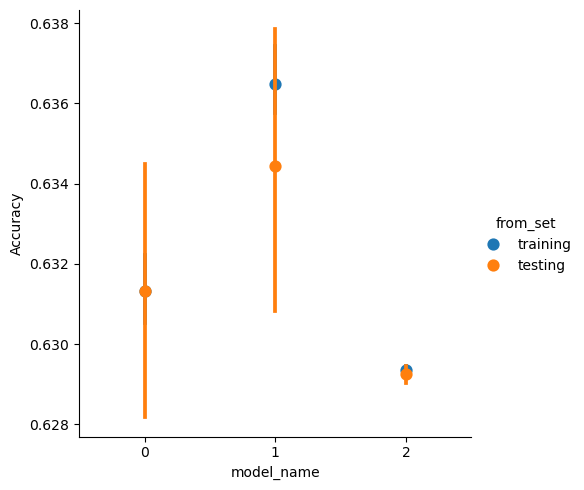

In [16]:
sns.catplot(data=cv_results, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False)

plt.show()

In [21]:
def train_and_test_logistic_standardized(mod_name, formula, data_df, inputs, output, cv, continuous_inputs, threshold=0.5):
    # Initialize the performance metric storage lists
    train_res = []
    test_res = []

    for train_id, test_id in cv.split(data_df[inputs], data_df[output]):
        # Split the data into training and testing sets
        train_data = data_df.iloc[train_id].copy()
        test_data = data_df.iloc[test_id].copy()

        # Standardize continuous features within the fold
        scaler = StandardScaler()
        train_data[continuous_inputs] = scaler.fit_transform(train_data[continuous_inputs])
        test_data[continuous_inputs] = scaler.transform(test_data[continuous_inputs])

        # Fit the logistic regression model
        a_mod = smf.logit(formula=formula, data=train_data).fit(disp=False)

        # Predict probabilities and classes on training set
        train_data['pred_probability'] = a_mod.predict(train_data)
        train_data['pred_class'] = (train_data['pred_probability'] > threshold).astype(int)

        # Predict probabilities and classes on testing set
        test_data['pred_probability'] = a_mod.predict(test_data)
        test_data['pred_class'] = (test_data['pred_probability'] > threshold).astype(int)

        # Calculate accuracy on training and testing sets
        train_res.append(np.mean(train_data[output] == train_data['pred_class']))
        test_res.append(np.mean(test_data[output] == test_data['pred_class']))

    # Store the results in DataFrames
    train_df = pd.DataFrame({'Accuracy': train_res})
    train_df['from_set'] = 'training'
    train_df['fold_id'] = train_df.index + 1

    test_df = pd.DataFrame({'Accuracy': test_res})
    test_df['from_set'] = 'testing'
    test_df['fold_id'] = test_df.index + 1

    # Combine the results and add metadata
    res_df = pd.concat([train_df, test_df], ignore_index=True)
    res_df['model_name'] = mod_name
    res_df['model_formula'] = formula
    res_df['num_coefs'] = len(a_mod.params)
    res_df['threshold'] = threshold

    return res_df

In [23]:
results_list_stand = []

for m in range( len(formula_list) ):
    print('-- Formula ID %d --' %m)

    try:
        results_list_stand.append( 
            train_and_test_logistic_standardized(
                m, 
                formula_list[m], 
                data_df=df, 
                inputs=input_names, 
                output=output, 
                cv=kf,
                continuous_inputs=continuous_inputs, 
                threshold=0.5)
        )
    except:
        print( '!!! Formula ID %d could not fit !!!' %m )

-- Formula ID 0 --
-- Formula ID 1 --
-- Formula ID 2 --


In [26]:
cv_results_stand = pd.concat( results_list_stand, ignore_index=True )
cv_results_stand

,Accuracy,from_set,fold_id,model_name,model_formula,num_coefs,threshold
0,0.630136,training,1,0,target ~ danceability + log_tempo + energy + p...,9,0.5
1,0.631739,training,2,0,target ~ danceability + log_tempo + energy + p...,9,0.5
2,0.630681,training,3,0,target ~ danceability + log_tempo + energy + p...,9,0.5
3,0.631122,training,4,0,target ~ danceability + log_tempo + energy + p...,9,0.5
4,0.632929,training,5,0,target ~ danceability + log_tempo + energy + p...,9,0.5
5,0.636460,testing,1,0,target ~ danceability + log_tempo + energy + p...,9,0.5
6,0.631987,testing,2,0,target ~ danceability + log_tempo + energy + p...,9,0.5
7,0.633751,testing,3,0,target ~ danceability + log_tempo + energy + p...,9,0.5
8,0.628108,testing,4,0,target ~ danceability + log_tempo + energy + p...,9,0.5
9,0.626345,testing,5,0,target ~ danceability + log_tempo + energy + p...,9,0.5


Model 1 is the best-performing model in terms of testing accuracy, and includes all three continuous features plus the categorical feature playlist_genre.

It demonstrates that including categorical inputs meaningfully improves performance, even if it increases the number of coefficients.

The balance between training and testing performance shows that the model is relatively robust and not overfitted, despite having a higher number of parameters.

C:\Users\User\AppData\Local\Temp\ipykernel_1708\806121302.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot(data=cv_results_stand, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, alpha=0.5)
C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


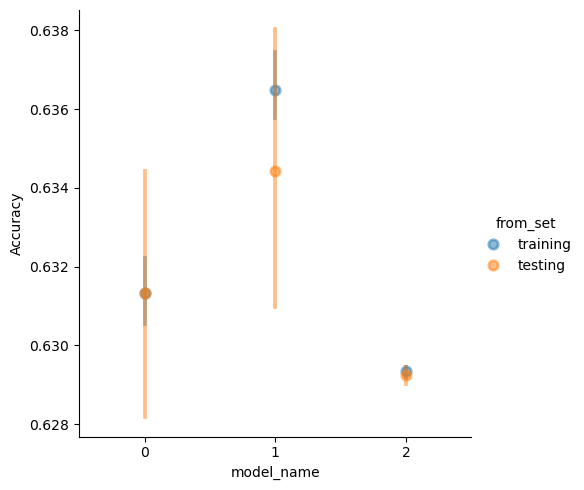

In [28]:
sns.catplot(data=cv_results_stand, x='model_name', y='Accuracy', hue='from_set', kind='point', join=False, alpha=0.5)

plt.show()

Model 1 is the best according to CROSS-VALIDATION. This model was the best in the training set. The best model has 24 coefficients.

#### Implementing regularization techniques Lasso, Ridge, and Elastic Net 

In [31]:
y_0, x_0 = dmatrices(formula_list[1], data=df)

In [33]:
x_0.shape

(28356, 24)

In [40]:
ridge_model = LogisticRegressionCV(penalty='l2', Cs=10, solver='lbfgs', max_iter=1000, cv=kf, fit_intercept=False).\
fit(x_0, y_0.ravel())

In [47]:
ridge_model.score(x_0, y_0.ravel())

0.6375370292001693

In [67]:
ridge_model.C_

array([10000.])

In [61]:
ridge_model.coef_

array([[-1.18017283, -0.44103492,  1.31176915, -0.12068268, -2.23943211,
        -0.1780759 , -0.89204839,  1.58974528,  1.99074565,  0.72413826,
         3.05512887,  1.49232147,  0.16820132,  0.04914869, -0.35090289,
         0.11869839,  0.29184752,  0.02246707, -0.74163021,  0.30098282,
         0.76646451, -0.43369673, -0.31016381,  0.4287785 ]])

In [44]:
lasso_model = LogisticRegressionCV(penalty='l1', Cs=10, solver='saga', max_iter=1000, cv=kf, fit_intercept=False).\
fit(x_0, y_0.ravel())

In [49]:
lasso_model.score(x_0, y_0.ravel())

0.6379602200592467

In [63]:
lasso_model.C_

array([21.5443469])

In [64]:
lasso_model.coef_

array([[-0.26450896, -1.41957845,  0.3321961 , -1.06505523, -3.15926526,
        -1.12917612, -0.98014877,  1.69234419,  2.08903576,  0.81476513,
         3.14809226,  1.58587752, -0.00432304,  0.23277835, -0.16650824,
         0.2964826 ,  0.46404137,  0.20187091, -0.76924367,  0.32806599,
         0.7947076 , -0.40267974, -0.27928012,  0.4556165 ]])

In [45]:
elastic_net = LogisticRegressionCV(penalty='elasticnet', solver='saga', max_iter=1000, fit_intercept=False,
                                  cv=kf, Cs=10, l1_ratios=np.linspace(0,1,num=4)).fit(x_0, y_0.ravel())

In [50]:
elastic_net.score(x_0, y_0.ravel())

0.6368317111017069

In [65]:
elastic_net.C_

array([2.7825594])

In [60]:
elastic_net.coef_

array([[-1.13681496, -0.41387758,  1.04499381, -0.13166486, -2.07477809,
        -0.18166704, -0.71438718,  1.38203469,  1.81758909,  0.53116717,
         2.8231457 ,  1.29389983,  0.12981923,  0.07798204, -0.26545654,
         0.15103756,  0.29523441,  0.0558483 , -0.70710755,  0.26142622,
         0.7248012 , -0.45748559, -0.34678911,  0.38760945]])

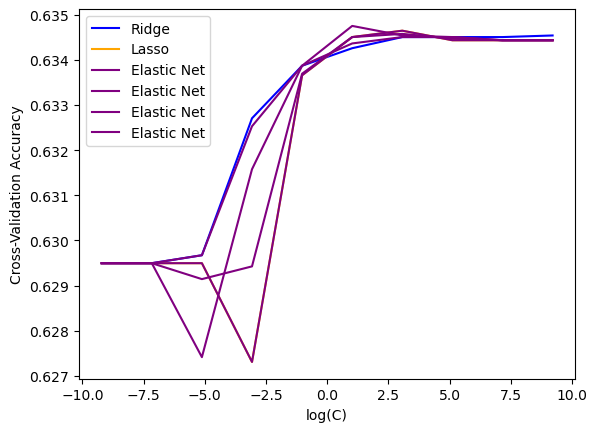

In [68]:
fig, ax = plt.subplots()

ax.plot( np.log( ridge_model.Cs_ ), ridge_model.scores_[1.0].mean(axis=0), color='blue', label='Ridge')
ax.plot( np.log( lasso_model.Cs_ ), lasso_model.scores_[1.0].mean(axis=0), color='orange', label='Lasso')
ax.plot( np.log( elastic_net.Cs_ ), elastic_net.scores_[1.0].mean(axis=0), color='purple', label='Elastic Net')

ax.set_xlabel('log(C)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.legend()

plt.show()

Regularization techniques yielded comparable accuracy in your project, with Lasso performing best by a small margin. Your model seems to benefit most from mild regularization, and the visual comparison supports the robustness and consistency across different penalty types as long as the strength is balanced.